In [1]:
# mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# load dataset
import zipfile
zip_ref = zipfile.ZipFile("/content/drive/MyDrive/Deep Learning/training_set.zip", 'r')
zip_ref.extractall("/content")
zip_ref.close()

In [3]:
# load dataset
import zipfile
zip_ref = zipfile.ZipFile("/content/drive/MyDrive/Deep Learning/test_set.zip", 'r')
zip_ref.extractall("/content")
zip_ref.close()

# Visualize some images from the dataset

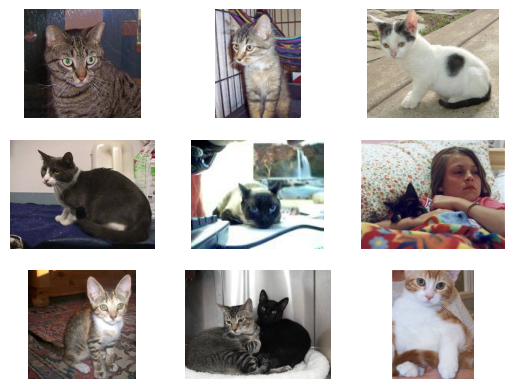

In [4]:
# print some images
import matplotlib.pyplot as plt
from matplotlib.image import imread

Folder='/content/training_set/cats/'

for i in range(9):
  plt.subplot(3,3,i+1)
  filename=Folder+'cat.'+str(i+1)+'.jpg'
  image=imread(filename)
  plt.imshow(image)
  plt.axis('off')
plt.show()

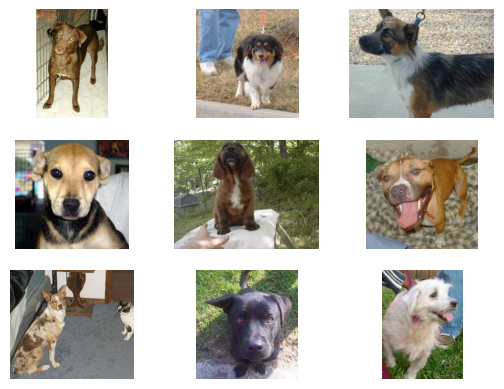

In [5]:
# print some images
import matplotlib.pyplot as plt
from matplotlib.image import imread

Folder='/content/training_set/dogs/'

for i in range(9):
  plt.subplot(3,3,i+1)
  filename=Folder+'dog.'+str(i+1)+'.jpg'
  image=imread(filename)
  plt.imshow(image)
  plt.axis('off')
plt.show()

# Data Augmentation/Image DataGenerator/ Data Preprocessing

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen=ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True)
test_datagen=ImageDataGenerator(rescale=1./255)

#Create Train set and test set

In [7]:
training_set=train_datagen.flow_from_directory('/content/training_set',
                                               target_size=(64,64),
                                               batch_size=32,
                                               class_mode='binary')

Found 8005 images belonging to 2 classes.


In [8]:
test_set=test_datagen.flow_from_directory('/content/test_set',
                                               target_size=(64,64),
                                               batch_size=32,
                                               class_mode='binary')

Found 2023 images belonging to 2 classes.


# Create Architecture

In [9]:
# import the library

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
print('Library imported')


Library imported


In [10]:
# Create Architecture

model=Sequential()
# first CNN layer
model.add(Conv2D(64,(3,3),activation='relu',input_shape=(64,64,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# second CNN Layer
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# third CNN layer
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Flatten
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
print('Model Created')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Created


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 31, 31, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 813,313 (3.10 MB)

 Trainable params: 813,313 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# complie the modle
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [13]:
# Training
history=model.fit(training_set,
                  epochs=10,
                  validation_data=test_set)
print('Training Completed')

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 177s 696ms/step - accuracy: 0.4916 - loss: 0.7116 - val_accuracy: 0.4948 - val_loss: 0.6896
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 595ms/step - accuracy: 0.5488 - loss: 0.6849 - val_accuracy: 0.5724 - val_loss: 0.6663
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 151s 600ms/step - accuracy: 0.5960 - loss: 0.6665 - val_accuracy: 0.6757 - val_loss: 0.6101
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 156s 620ms/step - accuracy: 0.6405 - loss: 0.6278 - val_accuracy: 0.7153 - val_loss: 0.5713
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 149s 596ms/step - accuracy: 0.6910 - loss: 0.5801 - val_accuracy: 0.7316 - val_loss: 0.5343
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 147s 587ms/step - accuracy: 0.7209 - loss: 0.5433 - val_accuracy: 0.7622 - val_loss: 0.4945
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 148s 589ms/step - accuracy: 0.7437 - loss: 0.5120 - val_accuracy: 0.7563 - val_loss: 0.5022
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 152s 606ms/step - accuracy: 0.7569 -

In [15]:
# print test score
score=model.evaluate(test_set)
print('Test loss:',score[0])
print('Test accuracy:',score[1])

64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 237ms/step - accuracy: 0.7675 - loss: 0.5045
Test loss: 0.49244385957717896
Test accuracy: 0.7740978598594666


In [16]:
# print train score
score=model.evaluate(training_set)
print('Train loss:',score[0])
print('Train accuracy:',score[1])

251/251 ━━━━━━━━━━━━━━━━━━━━ 49s 193ms/step - accuracy: 0.7719 - loss: 0.4693
Train loss: 0.47655755281448364
Train accuracy: 0.7653966546058655


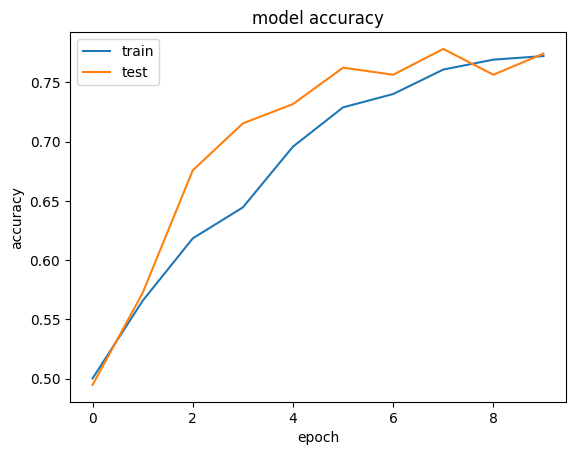

In [17]:
# plot the accuracy graph
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

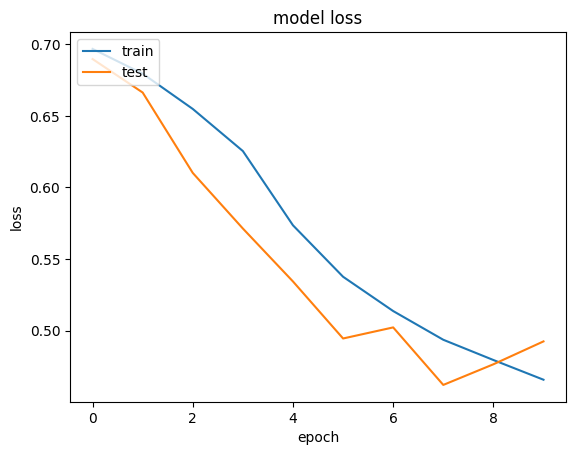

In [18]:
# loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [19]:
# save the model
model.save('catdog_model.keras')
print('model is saved')

model is saved


In [20]:
# load the keras model
from tensorflow.keras.models import load_model
model=load_model('catdog_model.keras')
print('model is loaded')

model is loaded


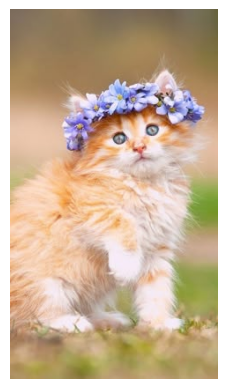

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
its a Cat


In [21]:
# pred on new image
from tensorflow.keras.preprocessing.image import load_img,img_to_array
import numpy as np


test_image=load_img('/content/c62e47ccce4e8e568c9c7e381032bde9.jpg')
plt.imshow(test_image)
plt.axis('off')
plt.show()


test_image=load_img('/content/c62e47ccce4e8e568c9c7e381032bde9.jpg',target_size=(64,64))
test_image=img_to_array(test_image)
test_image=np.expand_dims(test_image,axis=0)
result=model.predict(test_image)
if result[0][0]==1:
  print('its a Dog')
else:
  print('its a Cat')

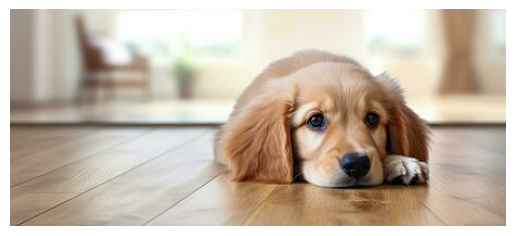

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
its a Dog


In [22]:
# pred on new image
from tensorflow.keras.preprocessing.image import load_img,img_to_array
import numpy as np


test_image=load_img('/content/cute-dog-rests-on-the-ground-photo.jpg')
plt.imshow(test_image)
plt.axis('off')
plt.show()


test_image=load_img('/content/cute-dog-rests-on-the-ground-photo.jpg',target_size=(64,64))
test_image=img_to_array(test_image)
test_image=np.expand_dims(test_image,axis=0)
result=model.predict(test_image)
if result[0][0]==1:
  print('its a Dog')
else:
  print('its a Cat')